## Практическая работа: 3 

# Тема: Случайный лес (Random Forest)

---

### Цель работы

Научиться применять модель случайного леса (Random Forest) для решения задач классификации и регрессии, познакомиться с принципами ансамблевого обучения, методом бэггинга, Out-of-Bag оценкой и важностью признаков.

## Теоретическая справка

**Случайный лес** (Random Forest) — ансамблевый алгоритм машинного обучения, основанный на принципе *«коллективный разум лучше индивидуального»*. 

Алгоритм объединяет множество деревьев решений, каждое из которых обучается на случайной подвыборке данных и признаков, что позволяет значительно снизить переобучение и повысить устойчивость модели.

### Принцип работы

1. Создать $B$ бутстрэп-выборок (случайный выбор $n$ объектов с возвращением из обучающей выборки размера $n$)
2. Для каждой бутстрэп-выборки построить дерево решений:
   - В каждом узле выбирать лучший признак из случайного подмножества размера $m$ (а не из всех $p$ признаков)
   - Выращивать дерево до максимальной глубины (без обрезки)
3. Агрегировать предсказания всех деревьев

### Формула предсказания для классификации

Финальное предсказание — класс, за который проголосовало большинство деревьев:
$$\hat{y} = \text{mode}\{h_1(x), h_2(x), ..., h_B(x)\}$$

**Обозначения:**
- $\hat{y}$ — предсказанный класс
- $\text{mode}$ — мода (наиболее часто встречающееся значение)
- $h_b(x)$ — предсказание $b$-го дерева для объекта $x$
- $B$ — общее число деревьев в ансамбле

### Формула предсказания для регрессии

Финальное предсказание — среднее предсказаний всех деревьев:
$$\hat{y} = \frac{1}{B} \sum_{b=1}^{B} h_b(x)$$

**Обозначения:**
- $\hat{y}$ — предсказанное значение
- $B$ — общее число деревьев в ансамбле
- $h_b(x)$ — предсказание $b$-го дерева для объекта $x$
- $\sum_{b=1}^{B}$ — сумма по всем деревьям от 1 до $B$

### Бэггинг (Bootstrap Aggregating)

**Бэггинг** — техника ансамблирования, лежащая в основе Random Forest:

| Этап | Описание |
|------|----------|
| **Bootstrap** | Создание $B$ выборок размера $n$ с возвращением из исходных $n$ объектов |
| **Обучение** | Обучение $B$ независимых моделей на этих выборках |
| **Aggregating** | Усреднение (регрессия) или голосование (классификация) |

**Статистический факт:** В каждую бутстрэп-выборку попадает в среднем $\approx 63.2\%$ уникальных объектов.

### Формула вероятности невключения объекта в бутстрэп-выборку

$$P(\text{объект не попал}) = \left(1-\frac{1}{n}\right)^n \approx \frac{1}{e} \approx 0.368$$

**Обозначения:**
- $n$ — размер исходной выборки
- $e \approx 2.718$ — основание натурального логарифма
- $\frac{1}{n}$ — вероятность выбрать конкретный объект за одну попытку

### Случайность признаков (Feature Randomness)

Помимо бэггинга, Random Forest добавляет **случайность при выборе признаков**:

| Параметр `max_features` | Значение | Когда использовать |
|-------------------------|----------|--------------------|
| `'sqrt'` | $m = \sqrt{p}$ | Классификация (по умолчанию) |
| `'log2'` | $m = \log_2(p)$ | Альтернатива для классификации |
| `None` или `1.0` | $m = p$ (все признаки) | Регрессия (по умолчанию) |
| `0.33` | $m = 0.33 \cdot p$ | Регрессия (рекомендуется) |

**Обозначения:**
- $p$ — общее число признаков в датасете
- $m$ — число признаков, из которых выбирается лучший в каждом узле дерева

**Зачем это нужно?** Если один признак очень информативен, все деревья будут похожи. Случайный выбор признаков делает деревья разнообразными (декоррелированными), что улучшает качество ансамбля.

### Out-of-Bag (OOB) оценка

**OOB-оценка** — уникальная особенность бэггинга, позволяющая оценить качество модели **без отдельной валидационной выборки**.

**Принцип:**
1. Каждый объект $x_i$ не попал примерно в 36.8% бутстрэп-выборок
2. Для объекта $x_i$ делаем предсказание только теми деревьями, которые его НЕ видели при обучении
3. Агрегируем эти «честные» предсказания
4. Сравниваем с истинной меткой $y_i$

### Формула OOB-ошибки для классификации

$$\text{OOB Error} = \frac{1}{n} \sum_{i=1}^{n} \mathbb{1}[\hat{y}_i^{OOB} \neq y_i]$$

**Обозначения:**
- $n$ — число объектов в обучающей выборке
- $\hat{y}_i^{OOB}$ — OOB-предсказание для $i$-го объекта
- $y_i$ — истинная метка $i$-го объекта
- $\mathbb{1}[\cdot]$ — индикаторная функция (возвращает 1, если условие истинно, иначе 0)
- $\sum_{i=1}^{n}$ — сумма по всем объектам от 1 до $n$

**Преимущества OOB:**
- Не требует выделения валидационной выборки
- Использует все данные для обучения
- Даёт несмещённую оценку ошибки обобщения
- Близка к оценке на тестовой выборке или кросс-валидации

**Использование:** Установить `oob_score=True` при создании модели, затем получить оценку через атрибут `oob_score_`.

### Важность признаков (MDI)

**MDI** (Mean Decrease Impurity) — усреднённое уменьшение примеси по всем деревьям:

$$\text{importance}(f) = \frac{1}{B} \sum_{b=1}^{B} \sum_{t \in T_b^f} \frac{n_t}{n} \cdot \Delta I_t$$

**Обозначения:**
- $f$ — признак, для которого вычисляется важность
- $B$ — число деревьев в ансамбле
- $T_b^f$ — множество узлов в дереве $b$, где разбиение происходит по признаку $f$
- $n_t$ — число объектов в узле $t$
- $n$ — общее число объектов в обучающей выборке
- $\Delta I_t$ — уменьшение примеси (Gini или Entropy) при разбиении в узле $t$

**⚠️ Важно:** MDI может давать завышенную важность для признаков с большим числом уникальных значений.

### Масштабирование данных

✅ **Случайный лес НЕ требует масштабирования данных!**

Как и отдельные деревья решений, Random Forest работает с пороговыми значениями признаков, поэтому масштаб не влияет на результат.

### Число деревьев (n_estimators)

| Значение | Эффект |
|----------|--------|
| Малое (10–50) | Высокая дисперсия, быстрое обучение |
| Среднее (100–200) | Оптимальный баланс |
| Большое (500+) | Минимальный выигрыш, долгое обучение |

**Важно:** В отличие от градиентного бустинга, Random Forest **не переобучается** при увеличении числа деревьев — качество выходит на плато.

### Регуляризация

Хотя Random Forest устойчив к переобучению благодаря ансамблированию, иногда требуется дополнительная регуляризация:

| Параметр | Эффект регуляризации |
|----------|----------------------|
| `max_depth` | Ограничение глубины деревьев |
| `min_samples_split` | Минимум объектов для разбиения |
| `min_samples_leaf` | Минимум объектов в листе |
| `max_features` | Меньше признаков → больше разнообразия |

### Критерий переобучения

| Метрика | Критерий переобучения |
|---------|----------------------|
| Train − OOB | > 5% — переобучение |

### Реализация в Scikit-learn

Основные классы:
- [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) — для классификации
- [`RandomForestRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) — для регрессии

**Ключевые параметры:**

| Параметр | Значения | Описание |
|----------|----------|----------|
| `n_estimators` | int (по умолчанию 100) | Число деревьев в лесу |
| `criterion` | `'gini'`, `'entropy'` (класс.) / `'squared_error'` (регр.) | Критерий разбиения |
| `max_depth` | int или None | Максимальная глубина деревьев |
| `min_samples_split` | int или float | Минимум для разбиения узла |
| `min_samples_leaf` | int или float | Минимум объектов в листе |
| `max_features` | `'sqrt'`, `'log2'`, int, float, None | Признаков для разбиения |
| `bootstrap` | bool (по умолчанию True) | Использовать бутстрэп |
| `oob_score` | bool (по умолчанию False) | Вычислять OOB-оценку |
| `n_jobs` | int | Число ядер (-1 = все) |
| `random_state` | int | Для воспроизводимости |

**Основные методы и атрибуты:**
- `fit(X, y)` — обучение модели
- `predict(X)` — предсказание для новых объектов
- `predict_proba(X)` — вероятности классов (только классификация)
- `score(X, y)` — оценка качества
- `feature_importances_` — важность признаков (MDI)
- `oob_score_` — OOB-оценка качества (если `oob_score=True`)
- `oob_decision_function_` — OOB-вероятности для каждого объекта (классификация)
- `oob_prediction_` — OOB-предсказания для каждого объекта (регрессия)
- `estimators_` — список обученных деревьев

### Дополнительные ресурсы

**Документация Scikit-learn:**
- 📖 [Официальная документация sklearn.ensemble](https://scikit-learn.org/stable/modules/ensemble.html#forest)
- 📖 [User Guide: Random Forests](https://scikit-learn.org/stable/modules/ensemble.html#random-forests)
- 📖 [Пример: Feature Importance](https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html)
- 📖 [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)
- 📖 [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)


---
### Импорт библиотек

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, validation_curve
from sklearn.metrics import (f1_score, confusion_matrix, classification_report, 
                             ConfusionMatrixDisplay, accuracy_score)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

Настраиваем параметры отображения и фиксируем random seed:

In [76]:
plt.rcParams['figure.figsize'] = (8, 5)
np.random.seed(42)

## Классификация
# Задания для выполнения:

Использовать датасет **Ionosphere** для классификации радарных сигналов.

**Ссылки на датасет:**
- 📊 [Ionosphere на Kaggle](https://www.kaggle.com/datasets/prashant111/ionosphere)
- 📊 [Ionosphere на UCI ML Repository](https://archive.ics.uci.edu/dataset/52/ionosphere)

### План работы:
1. Загрузить и исследовать данные
2. Разделить данные на train/test
3. Обучить модель Random Forest с параметрами по умолчанию
4. Вычислить Out-of-Bag (OOB)
5. Оценить переобучение дефолтной модели через OOB
6. Сравнить Out-of-Bag (OOB) с результатами кросс-валидации
7. Определить оптимальное число деревьев по OOB-оценке
8. Подобрать гиперпараметры (GridSearchCV)
9. Проанализировать на переобученность
10. Оценить качество на тестовых данных
11. Проанализировать важность признаков
12. Визуализировать границы решений

---

### Задание 1. Загрузить и исследовать данные

Загрузить датасет Ionosphere. Дать названия столбцам `feature_1`, `feature_2` и т.д., а целевую переменную назвать `target`. Вывести первые 5 строк датафрейма, его размеры, информацию о данных, базовую статистику и распределение целевой переменной. Проверить, что в данных нет пропущенных значений. Выделить матрицу признаков $X$ и вектор целевой переменной $y$ (столбец target) в виде NumPy-массивов. Перевести значения целевой переменной $y$ в числовые, обозначив g=1, b=0.

**Указание**: При загрузке данных с помощью метода `read_csv` указать `header=None`.

In [77]:
df=pd.read_csv('ionosphere.csv')
feature_names=[f'feature_{i}' for i in range (df.shape[1]-1)]+['target']
df.columns=feature_names
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,target
0,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,b
1,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,g
2,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,b
3,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,g
4,1,0,0.02337,-0.00592,-0.09924,-0.11949,-0.00763,-0.11824,0.14706,0.06637,...,-0.01535,-0.03240,0.09223,-0.07859,0.00732,0.00000,0.00000,-0.00039,0.12011,b


In [78]:
df.shape

(350, 35)

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 35 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature_0   350 non-null    int64  
 1   feature_1   350 non-null    int64  
 2   feature_2   350 non-null    float64
 3   feature_3   350 non-null    float64
 4   feature_4   350 non-null    float64
 5   feature_5   350 non-null    float64
 6   feature_6   350 non-null    float64
 7   feature_7   350 non-null    float64
 8   feature_8   350 non-null    float64
 9   feature_9   350 non-null    float64
 10  feature_10  350 non-null    float64
 11  feature_11  350 non-null    float64
 12  feature_12  350 non-null    float64
 13  feature_13  350 non-null    float64
 14  feature_14  350 non-null    float64
 15  feature_15  350 non-null    float64
 16  feature_16  350 non-null    float64
 17  feature_17  350 non-null    float64
 18  feature_18  350 non-null    float64
 19  feature_19  350 non-null    f

In [80]:
df.describe()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33
count,350.000000,350.0,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,...,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,0.891429,0.0,0.640330,0.044667,0.600350,0.116154,0.549284,0.120779,0.510453,0.181756,...,0.395643,-0.069928,0.542015,-0.068417,0.378919,-0.027013,0.352313,-0.002248,0.349829,0.015816
std,0.311546,0.0,0.498059,0.442032,0.520431,0.461443,0.493124,0.520816,0.507117,0.484482,...,0.579206,0.508675,0.516896,0.550411,0.576642,0.508425,0.572289,0.513491,0.523339,0.468338
min,0.000000,0.0,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,1.000000,0.0,0.471517,-0.065388,0.412555,-0.024868,0.209105,-0.053483,0.086785,-0.049003,...,0.000000,-0.323745,0.283612,-0.428992,0.000000,-0.234935,0.000000,-0.239347,0.000000,-0.161013
50%,1.000000,0.0,0.870795,0.016700,0.808620,0.021170,0.728000,0.015085,0.682430,0.017550,...,0.549175,-0.014915,0.708530,-0.017685,0.499215,0.000000,0.446875,0.000000,0.413115,0.000000
75%,1.000000,0.0,1.000000,0.194727,1.000000,0.335317,0.970445,0.451572,0.950555,0.536192,...,0.907165,0.157922,0.999972,0.154862,0.884572,0.154218,0.859490,0.200935,0.816778,0.172105
max,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [81]:
df['target'].value_counts()

target
g    224
b    126
Name: count, dtype: int64

In [82]:
df.isnull()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,target
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
346,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
347,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
348,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [83]:
X=df.iloc[:,:-1]
y=(df['target'] == 'g').values.astype(int)
y

array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

### Задание 2. Разделить данные на train/test

Разделить данные на обучающую и тестовую выборки в соотношении 75/25 со стратификацией по целевой переменной. Вывести число объектов и распределение классов в полученных выборках.

**Указание:** Использовать `train_test_split()` с `stratify=y` и `random_state=42`. Использоввть `np.bincount` для распределения классов.

In [84]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,stratify=y,random_state=42)
X_train.shape[0],X_test.shape[0]

(262, 88)

In [85]:
np.bincount(y_train)

array([ 94, 168])

In [86]:
np.bincount(y_test)

array([32, 56])

### Задание 3. Обучить модель с параметрами по умолчанию

Создать экземпляр класса `RandomForestClassifier` с параметрами по умолчанию и вывести значения параметров. Обучить дефолтную модель на обучающих данных. Вывести список базовых алгоритмов деревьев, участвующих в модели случайного леса.

**Указание:** Установить у дефолтной модели `oob_score=True`(включить расчёт OOB-оценки), `random_state=42` и для ускорения `n_jobs=-1`. Для вывода базовых алгоритмов деревьев использовать атрибут `estimators_`. 

In [87]:
rf_default=RandomForestClassifier(oob_score=True,random_state=42,n_jobs=-1)
rf_default.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': -1,
 'oob_score': True,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [88]:
rf_default.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [89]:
rf_default.estimators_[:5]

[DecisionTreeClassifier(max_features='sqrt', random_state=1608637542),
 DecisionTreeClassifier(max_features='sqrt', random_state=1273642419),
 DecisionTreeClassifier(max_features='sqrt', random_state=1935803228),
 DecisionTreeClassifier(max_features='sqrt', random_state=787846414),
 DecisionTreeClassifier(max_features='sqrt', random_state=996406378)]

### Задание 4. Вычислить Out-of-Bag (OOB)

Вывести `OOB Accuracy`. Рассчитать `OOB F1`, предварительно выведя OOB-вероятности для каждого объекта (быть отнесёнными к каждому классу) и получив по ним OOB-предсказания, преобразуя вероятности в метки классов. Использовать полученные предсказания для рассчёта F1-score.

**Указание:** Для вывода `OOB Accuracy` использовать атрибут `oob_score_`. Для вывода матрицы OOB-вероятностей использовать атрибут `oob_decision_function_`. Преобразование вероятности в метку класса осуществлять с использованием `argmax`, беря индекс максимального значения по строке (`axis=1`).

In [90]:
oob_accuracy=rf_default.oob_score_

In [91]:
oob_prod=rf_default.oob_decision_function_
oob_prod[:5]


array([[0.        , 1.        ],
       [0.        , 1.        ],
       [0.91111111, 0.08888889],
       [0.94444444, 0.05555556],
       [0.        , 1.        ]])

In [92]:
oob_pred=np.argmax(oob_prod,axis=1)
oob_pred[:5]

array([1, 1, 0, 0, 1])

In [93]:
oob_f1=f1_score(y_train,oob_pred)
oob_f1

0.9476744186046512

### Задание 5. Oценить переобучение дефолтной модели через OOB
Осуществить быструю проверку дефолтной модели на переобучение по метрикам Accuracy и F1 с использованием OOB. 

**Указание:**  Использовать критерий переобучения: Train score − OOB score > 5%.        

In [94]:
train_accuracy=rf_default.score(X_train,y_train)
train_accuracy

1.0

In [95]:
train_accuracy-oob_accuracy<0.85

True

In [96]:
train_f1=f1_score(y_train,rf_default.predict(X_train))
train_f1

1.0

### Задание 6. Сравнить Out-of-Bag (OOB) с результатами кросс-валидации

Построить `OOB Accuracy` в зависимости от числа деревьев на одном графике с валидационной кривой для гиперпараметра "число деревьев" по метрике Accuracy. По графику убедиться:

1. `OOB Accuracy` близка к `Validation Accuracy (CV)`.
2. `OOB Accuracy` ≈ `Validation Accuracy (CV)`- выходит на плато (стабилизируется и перестаёт расти), т.е. модель случайного леса не переобучается по количеству деревьев

**Указание:** Обучить несколько моделей с разным числом деревьев `n_trees_range = [10, 25, 50, 75, 100, 150, 200, 250, 300]`. Построить на одном графике `Train Accuracy (CV)` и `Validation Accuracy (CV)` от`n_estimators` (используя `validation_curve` с cv=5), а также `OOB Accuracy` (через `oob_score=True`) в зависимости от`n_estimators`. 

In [98]:
n_trees_range = [10, 25, 50, 75, 100, 150, 200, 250, 300]
train_scores,val_scores=validation_curve(RandomForestClassifier(random_state=42,n_jobs=-1),
                                        X_train,y_train,
                                        param_name='n_estimators',
                                        param_range=n_trees_range,
                                        cv=5,
                                        scoring='accuracy')
train_mean=train_scores.mean(axis=1)
val_mean=val_scores.mean(axis=1)

In [101]:
oob_scores=[]
for n_trees in n_trees_range:
    rf=RandomForestClassifier(n_estimators=n_trees,oob_score=True,random_state=42,n_jobs=-1)
    rf.fit(X_train,y_train)
    oob_scores.append(rf.oob_score_)

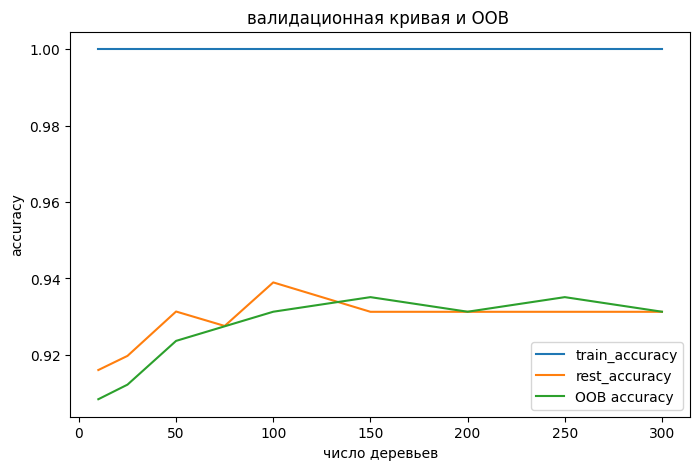

In [102]:
plt.plot(n_trees_range,train_mean,label='train_accuracy')
plt.plot(n_trees_range,val_mean,label='rest_accuracy')
plt.plot(n_trees_range,oob_scores,label='OOB accuracy')

plt.title('валидационная кривая и OOB ')
plt.legend()
plt.xlabel('число деревьев')
plt.ylabel('accuracy')

plt.show()

### Задание 7. Определить оптимальное число деревьев по OOB-оценке

По построенной зависимости OOB-оценки от числа деревьев в предыдущем задании, определить точку плато — минимальное число деревьев, после которого качество перестаёт расти. В качестве оптимального числа деревьев использовать значение немного выше точки плато (×2) для надёжности.

**Указание:** Точку выхода на плато находить, как первую точку, где достигнуто 99% от максимального OOB. 

### Задание 8. Подобрать гиперпараметры (GridSearchCV)

Подобрать оптимальные гиперпараметры модели с помощью GridSearchCV. 

**Указание:**  Использовать сетку гиперпараметров (слабая регуляризация):
- `n_estimators`: `[оптимальное],`
- `max_depth`: `[15, None],`
- `min_samples_split`: `[2, 10, 15]`
- `min_samples_leaf`: `[1, 5, 8]`
- `max_features`: `[None, 0.8]`

Не использовать `return_train_score=True`.

---
### Задание 9. Проанализировать на переобученность

Проверить лучшую модель из GridSearchCV на переобучение по метрике Accuracy с использованием OOB-ошибки. Для этого обучить модель `RandomForestClassifier` с лучшими гиперпараметрами, указав oob_score=True. Оценить переобученность по критерию: Train F1 − OOB F1 > 5%.

Если переобучение обнаружено — ужесточить регуляризацию в сетке параметров и запустить GridSearchCV повторно.

**Указание:** Взять регуляризованную сетку:
-    `'n_estimators': [оптимальное],        # Не влияет на переобучение`
-    `'max_depth': [3, 5, 7],                             # Было: [15, None] → уменьшить`
-    `'min_samples_split': [15, 20, 25],                  # Было: [2, 10, 15] → увеличить`
-    `'min_samples_leaf': [8, 10, 15],                    # Было: [1, 5, 8] → увеличить`
-    `'max_features': ['sqrt', 'log2']                    # Было: [None, 0.8] → уменьшить`


### Задание 10. Оценить качество на тестовых данных

Оценить качество лучшей модели на тестовой выборке. Вывести матрицу ошибок на тепловой карте и отчёт о классификации.

### Задание 11. Проанализировать важность признаков

Вывести и визуализировать важность признаков.

**Указание:** Для вывода важности признаков использовать атрибут `feature_importances_`. Для визуализации - горизонтальную столбчатую диаграмму `barh`.

### Задание 12. Визуализировать границы решений

Построить визуализацию границ решений для лучшей модели случайного леса по двум признакам с наибольшей важностью в пространстве обучающих данных на одном графике с диаграммой рассеяния тестовых данных. Для этого выбрать два признака с наибольшей важностью, обучить модель случайного леса с лучшими параметрами.

**Указание:** Использовать `np.meshgrid()` для создания сетки и `plt.contourf()` для раскраски областей. Использовать метод `model.predict_proba` для получения вероятностей принадлежности к классу. Это позволяет построить "карту уверенности" модели: яркий цвет — модель уверена в предсказании, бледный цвет — модель "сомневается" (вероятность близка к 0.5). 

---

## Часть 2. Регрессия

Использовать датасет **California Housing** для предсказания стоимости жилья.

**Ссылки на датасет:**
- 📊 [California Housing в sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html)
- 📊 [California Housing на Kaggle](https://www.kaggle.com/datasets/camnugent/california-housing-prices)

### План работы:

1. Загрузить и исследовать данные
2. Разделить данные на train/test
3. Обучить модель с параметрами по умолчанию
4. Вычислить OOB-оценку для регрессии
5. Оценить переобучение дефолтной модели через OOB
6. Определить оптимальное число деревьев по OOB-оценке
7. Подобрать гиперпараметры (GridSearchCV)
8. Проанализировать на переобученность
9. Оценить качество на тестовых данных
10. Проанализировать важность признаков


### Задание 1. Загрузить и исследовать данные

Загрузить датасет California Housing. Обозначить NumPy-массив признаков за X, а целевую переменную за y, вывести их размеры. Вывести названия признаков. Вывести первые 5 строк признаков вместе с целевой переменной в виде датафрейма, базовую статистику и проверить, что в данных нет пропущенных значений. Для ускорения вычислений взять случайную подвыборку из 5000 объектов.

**Указание:** Использовать функцию [`fetch_california_housing()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html). 

In [15]:
data = fetch_california_housing()
X = data.data
y = data.target

X.shape, y.shape

((20640, 8), (20640,))

In [9]:
data.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [21]:
indices = np.random.choice(len(X), 5000)
X = X[indices]
y = y[indices]

In [22]:
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,2.2328,52.0,3.665148,1.161731,1155.0,2.630979,37.75,-122.42,2.500
1,2.8750,29.0,4.182065,1.067935,1460.0,1.983696,33.77,-118.16,2.325
2,6.3654,26.0,7.361065,1.024958,1839.0,3.059900,34.45,-119.84,3.312
3,4.5701,5.0,5.965318,1.050096,1760.0,3.391137,37.65,-121.05,1.464
4,5.3279,23.0,5.731092,0.953782,638.0,2.680672,34.42,-119.73,4.139


In [11]:
print(df.describe())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude        target  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

In [12]:
print(df.isnull().sum())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64


### Задание 2. Разделить данные на train/test

Разделить данные на обучающую и тестовую выборки в соотношении 80/20. Вывести число объектов в полученных выборках.

**Указание:** Использовать `train_test_split()` с `random_state=42`.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((4000, 8), (1000, 8))

### Задание 3. Обучить модель с параметрами по умолчанию

Создать экземпляр класса `RandomForestRegressor` с параметрами по умолчанию и вывести значения параметров. Обучить дефолтную модель на обучающих данных. Вывести список базовых алгоритмов деревьев, участвующих в модели случайного леса.

**Указание:** Установить `oob_score=True` (включить расчёт OOB-оценки), `random_state=42` и `n_jobs=-1` для ускорения.

In [24]:
rf_default_reg = RandomForestRegressor(oob_score=True, random_state=42, n_jobs=-1)
rf_default_reg.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': -1,
 'oob_score': True,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [25]:
rf_default_reg.fit(X_train, y_train)
rf_default_reg.estimators_

[DecisionTreeRegressor(max_features=1.0, random_state=1608637542),
 DecisionTreeRegressor(max_features=1.0, random_state=1273642419),
 DecisionTreeRegressor(max_features=1.0, random_state=1935803228),
 DecisionTreeRegressor(max_features=1.0, random_state=787846414),
 DecisionTreeRegressor(max_features=1.0, random_state=996406378),
 DecisionTreeRegressor(max_features=1.0, random_state=1201263687),
 DecisionTreeRegressor(max_features=1.0, random_state=423734972),
 DecisionTreeRegressor(max_features=1.0, random_state=415968276),
 DecisionTreeRegressor(max_features=1.0, random_state=670094950),
 DecisionTreeRegressor(max_features=1.0, random_state=1914837113),
 DecisionTreeRegressor(max_features=1.0, random_state=669991378),
 DecisionTreeRegressor(max_features=1.0, random_state=429389014),
 DecisionTreeRegressor(max_features=1.0, random_state=249467210),
 DecisionTreeRegressor(max_features=1.0, random_state=1972458954),
 DecisionTreeRegressor(max_features=1.0, random_state=1572714583),
 De

### Задание 4. Вычислить OOB-оценку для регрессии

Вывести `OOB R²` — коэффициент детерминации, вычисленный по OOB-предсказаниям. Вывести OOB MSE — среднеквадратичную ошибку, вычисленную по OOB-предсказаниям.

**Указание:** Для вывода `OOB R²` использовать атрибут `oob_score_`. В регрессии `oob_score_` возвращает R² напрямую (в отличие от классификации, где это accuracy). Для вывода OOB-предсказаний использовать атрибут `oob_prediction_`.

In [26]:
oob_r2 = rf_default_reg.oob_score_
oob_r2

0.8723730624583299

In [27]:
oob_pred = rf_default_reg.oob_prediction_
oob_mse = mean_squared_error(y_train, oob_pred)
oob_mse

0.16664283963291823

### Задание 5. Оценить переобучение дефолтной модели через OOB

Осуществить быструю проверку дефолтной модели на переобучение по метрике R² с использованием OOB.

**Указание:** Использовать критерий переобучения: Train R² − OOB R² > 5%.

In [28]:
train_r2 = rf_default_reg.score(X_train, y_train)
train_r2

0.9823783275922959

In [29]:
oob_r2

0.8723730624583299

In [30]:
(train_r2 - oob_r2 )> 0.05

True

### Задание 6. Определить оптимальное число деревьев по OOB-оценке

Построить зависимость `Train R²`(без кросс-валидации) и `OOB R²` от числа деревьев на одном графике. Определить точку плато, как первую точку, где достигнуто 99% от максимального OOB. Для определения оптимального числа деревьев точку плато умножить на два.

**Указание:** Обучить несколько моделей с разным числом деревьев `n_trees_range = [25, 50, 75, 100, 150, 200]`.

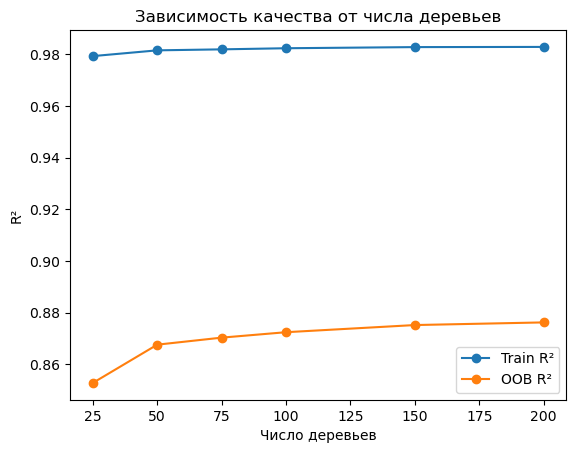

In [36]:
n_trees_range = [25, 50, 75, 100, 150, 200]
train_scores = []
oob_scores = []

for n_trees in n_trees_range:
    rf = RandomForestRegressor(n_estimators=n_trees, oob_score=True, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    train_scores.append(rf.score(X_train, y_train))
    oob_scores.append(rf.oob_score_)

plt.plot(n_trees_range, train_scores, label='Train R²', marker='o')
plt.plot(n_trees_range, oob_scores, label='OOB R²', marker='o')
plt.xlabel('Число деревьев')
plt.ylabel('R²')
plt.title('Зависимость качества от числа деревьев')
plt.legend()
plt.show()

In [41]:
max_oob = max(oob_scores)
threshold = 0.99 * max_oob
for i, score in enumerate(oob_scores):
    if score >= threshold:
        plateau_point = n_trees_range[i]
        break

optimal_n_trees = plateau_point * 2
print(f"Точка плато: {plateau_point} ")
print(f"Оптимальное число деревьев: {optimal_n_trees}")

Точка плато: 50 
Оптимальное число деревьев: 100


### Задание 7. Подобрать гиперпараметры (GridSearchCV)

Подобрать оптимальные гиперпараметры модели с помощью GridSearchCV.

**Указание:** Использовать сетку гиперпараметров (слабая регуляризация):
- `n_estimators`: `[оптимальное]`
- `max_depth`: `[10, 15, 20, None]`
- `min_samples_split`: `[2, 5, 10]`
- `min_samples_leaf`: `[1, 2, 4]`
- `max_features`: `[0.3, 0.5, 1.0]`

Использовать `scoring='r2'` и `cv=3`.

In [42]:
param_grid = {
    'n_estimators': [optimal_n_trees],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [0.3, 0.5, 1.0]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                          param_grid, cv=3, scoring='r2')
grid_search.fit(X_train, y_train)

grid_search.best_params_

{'max_depth': 20,
 'max_features': 0.5,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100}

In [43]:
grid_search.best_score_

0.8407372281508915

### Задание 8. Проанализировать на переобученность

Проверить лучшую модель из GridSearchCV на переобучение по метрике R² с использованием OOB-оценки. Для этого обучить модель `RandomForestRegressor` с лучшими гиперпараметрами, указав `oob_score=True`.

**Указание:** Использовать критерий переобучения: Train R² − OOB R² > 5%. Если переобучение обнаружено — ужесточить регуляризацию в сетке параметров.

Взять регуляризованную сетку:
-   `'n_estimators': [оптимальное],            # Не влияет на переобучение`
-   `'max_depth': [3, 4, 5],                  # Было: [10, 15, 20, None] → уменьшить`
-   `'min_samples_split': [20, 30, 50],        # Было: [2, 5, 10] → увеличить`
-   `'min_samples_leaf': [10, 15, 20],           # Было: [1, 2, 4] → увеличить`
-   `'max_features': [0.3, 0.5]               # Было: [0.3, 0.5, 1.0] → меньше данных, убрать 1.0`


In [47]:
best_rf = RandomForestRegressor(**grid_search.best_params_, oob_score=True, random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train)

train_r2 = best_rf.score(X_train, y_train)
oob_r2 = best_rf.oob_score_

train_r2

0.983339537123892

In [48]:
oob_r2

0.8807061047533541

In [49]:
if train_r2 - oob_r2 > 0.05:
    print("Есть переобучение")
else:
    print("Нет переобучения")

Есть переобучение


### Задание 9. Оценить качество на тестовых данных

Оценить качество лучшей модели на тестовой выборке. Вывести метрики R², MAE, RMSE. Визуализировать результаты: построить диаграмму рассеяния истинных и предсказанных значений и распределение ошибок.

**Указание:** Для визуализации распределение ошибок (остатков) модели вычислить остатки: `residuals = y_test - y_pred`, построить гистограмму остатков с помощью `plt.hist()` и добавить вертикальную линию в точке 0 с помощью `plt.axvline(x=0)`.

Интерпретация: Если модель хорошая, остатки должны быть распределены симметрично около нуля (близко к нормальному распределению).

In [50]:
y_pred = best_rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
r2

0.8825854197057036

In [51]:
mae = mean_absolute_error(y_test, y_pred)
mae

0.22983675958515182

In [52]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae

0.22983675958515182

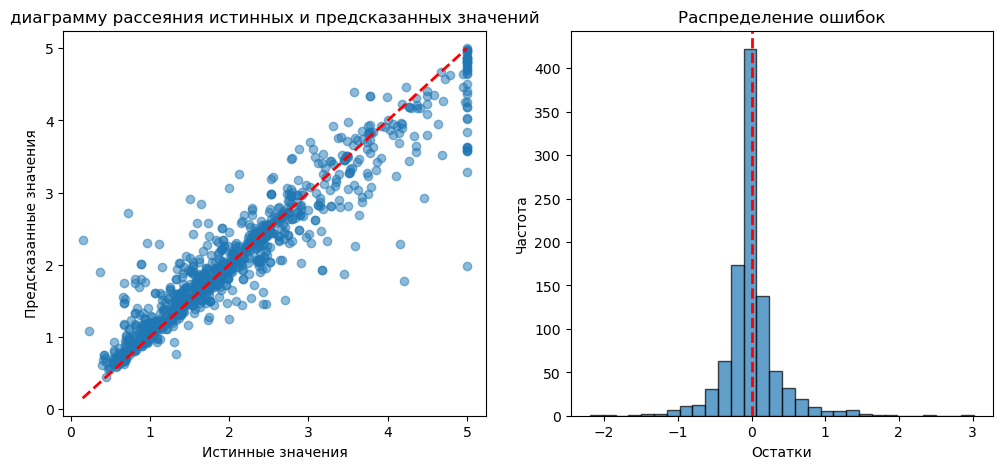

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_pred, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Истинные значения')
axes[0].set_ylabel('Предсказанные значения')
axes[0].set_title('диаграмму рассеяния истинных и предсказанных значений')

residuals = y_test - y_pred
axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Остатки')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение ошибок')

plt.show()

### Задание 10. Проанализировать важность признаков

Вывести и визуализировать важность признаков для задачи регрессии.

**Указание:** Для вывода важности признаков использовать атрибут `feature_importances_`. Для визуализации — горизонтальную столбчатую диаграмму `barh`.

In [64]:
importances = best_rf.feature_importances_
feature_names = data.feature_names

indices = np.argsort(importances)[::-1]

for i in indices:
    print(f"{feature_names[i]}: {importances[i]:.4f}")

MedInc: 0.4270
AveOccup: 0.1337
Latitude: 0.1057
Longitude: 0.1037
AveRooms: 0.0923
HouseAge: 0.0613
AveBedrms: 0.0416
Population: 0.0347


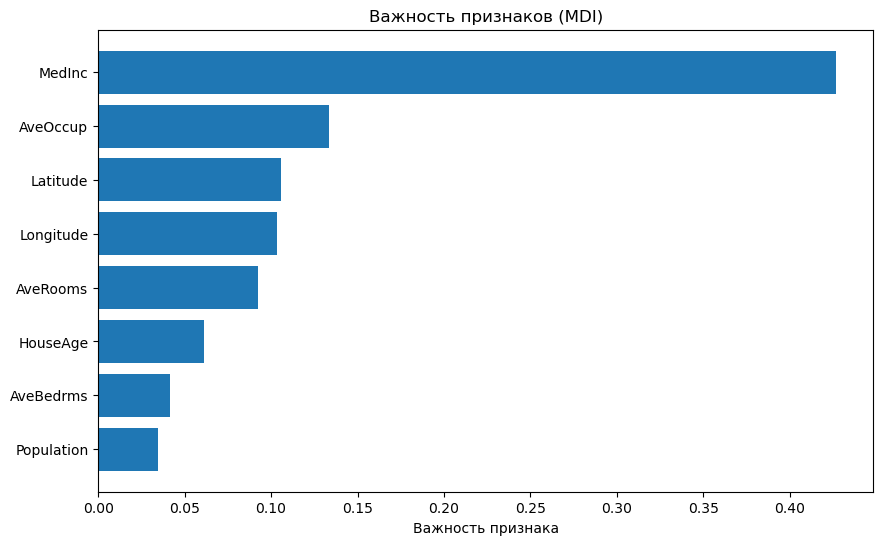

In [65]:
plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances[indices])
plt.yticks(range(len(importances)), [feature_names[i] for i in indices])
plt.xlabel('Важность признака')
plt.title('Важность признаков (MDI)')
plt.gca().invert_yaxis()
plt.show()